In [58]:
from pathlib import Path
from tqdm import tqdm
import json
tqdm.pandas()
#
import biotite.sequence as seq
import biotite.sequence.io.fasta as fasta
from biotite.sequence.align import Alignment
import biotite.sequence.graphics as graphics
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

#### Sequence filtering

In [25]:
# visualize sequences designed
def plot_seqs(folder, structure_name, start=0, show_seqs=5, scheme='zappo'):
    # read df of sequences (not incl input)
    df = pd.read_csv(
        f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/{folder}/seqs/seqs.csv'
    )
    df = df[df['id'].str.contains(structure_name)]

    # "align" (stack) sequences
    alignment = Alignment(
        [
            seq.ProteinSequence(s)
            for s in df['sequence']
        ],
        Alignment.trace_from_strings(list(df['sequence']))
    )

    # plot sequence logo
    profile = seq.SequenceProfile.from_alignment(alignment)
    fig, ax = plt.subplots(figsize=(18, 3))
    graphics.plot_sequence_logo(
        ax,
        profile,
        scheme=scheme
    )
    ax.set_xlabel('residue', fontsize=20, fontweight='bold')
    ax.set_ylabel('bits', fontsize=20, fontweight='bold')
    ax.set_xlim(start, ax.get_xlim()[1])
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    fig.tight_layout()
    plt.show()

    # plot first few sequences
    fig, ax = plt.subplots(figsize=(18, 6))
    graphics.plot_alignment_type_based(
        ax,
        alignment[:, :show_seqs],
        labels=list(df.index[:show_seqs]),
        show_numbers=True,
        color_scheme=scheme,
        color_symbols=True,
        symbols_per_line=int(len(df.iloc[0, 1]) / 2), #type: ignore
        symbol_size = 24,
        spacing = 1
    )
    fig.tight_layout()
    plt.show()

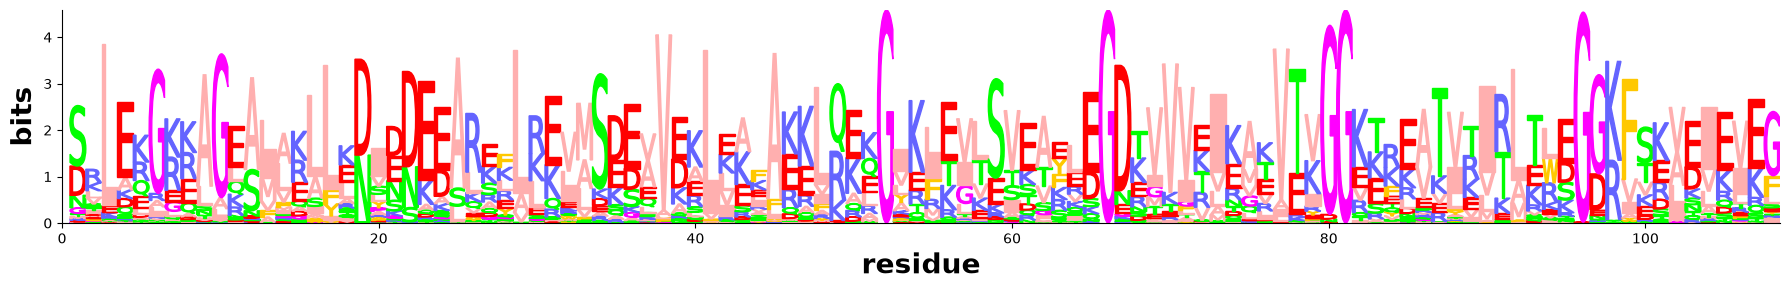

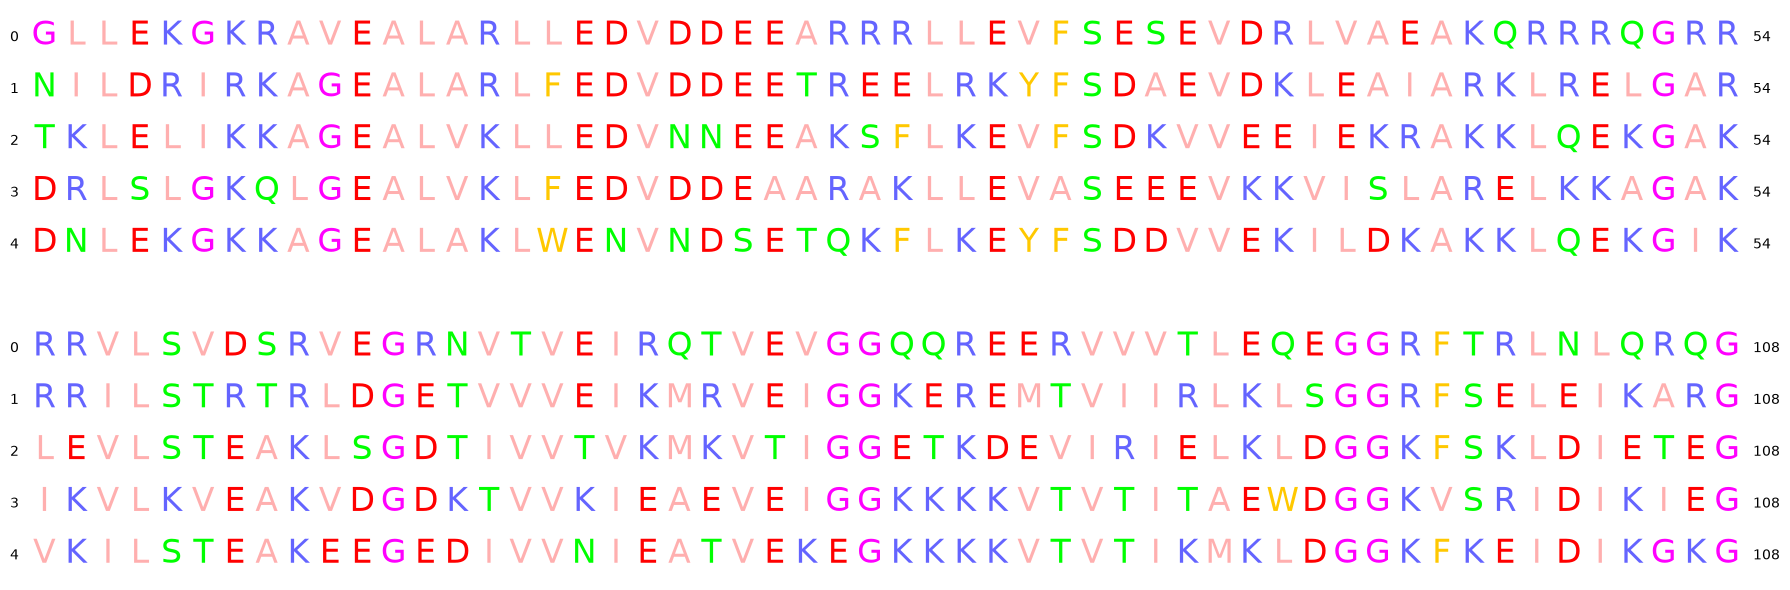

In [50]:
plot_seqs('5KPE-5KPH_multi-state2/temp3', '5KPE')

In [59]:
# read in sequences
dfs = {
    '0.1': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp1/seqs/seqs.csv'),
    '0.2': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp2/seqs/seqs.csv'),
    '0.3': pd.read_csv(f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state/temp3/seqs/seqs.csv')
}

In [60]:
# filter out runs
def longest_run(input):
    prev_char = None
    longest_run = 0
    current_run = 0

    for character in input:
        if character == prev_char:
            current_run += 1
        else:
            current_run = 0
            prev_char = character
        #
        if current_run > longest_run:
            longest_run = current_run
    #
    return longest_run

max_run = 4
def filter_runs(sequence):
    return longest_run(sequence) < max_run

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_runs)
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

For temp 0.1, 4113 of 4128 remain
For temp 0.2, 4111 of 4128 remain
For temp 0.3, 4109 of 4128 remain


In [61]:
max_comp = 0.25
enriched_aas = []
def filter_lcp(sequence):
    sequence_array = np.array(list(sequence))
    aas, counts = np.unique(sequence_array, return_counts=True)
    comp = np.max(counts) / len(sequence)
    if comp < max_comp:
        return True
    else:
        enriched_aas.append(aas[np.argmax(counts)])
        return False

for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(filter_lcp) #type:ignore
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

# print which AAs enriched > threshold
enriched_aa, enriched_count = np.unique(enriched_aas, return_counts=True)
for (aa, count) in zip(enriched_aa, enriched_count):
    print(f'{aa}: {count}')

For temp 0.1, 1832 of 4113 remain
For temp 0.2, 2508 of 4111 remain
For temp 0.3, 3332 of 4109 remain
E: 4181
K: 467
L: 4
R: 9


In [62]:
for temp in dfs:
    # filter out sequences
    mask = dfs[temp]['sequence'].apply(
        lambda sequence: 'W' in sequence
    ) #type:ignore
    filtered_df = dfs[temp][mask]

    # report stats
    print(f'For temp {temp}, {len(filtered_df)} of {len(dfs[temp])} remain')

    # keep filtered
    dfs[temp] = filtered_df.copy()

For temp 0.1, 426 of 1832 remain
For temp 0.2, 586 of 2508 remain
For temp 0.3, 786 of 3332 remain


In [ ]:
# check # of unique backbones remaining
def backbone(name):
    return '_'.join(name.split('_')[:5])

backbones_original = []
for temp in dfs:
    backbones = dfs[temp]['id'].apply(backbone)
    backbones_original.append(np.unique(backbones))

for backbones in backbones_original:
    print(len(backbones))

84
106
129


In [55]:
# save filtered dfs
for temp in dfs:
    save_path = f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/5KPE-5KPH_multi-state2/temp{temp[-1]}/seqs/filtered-seqs.csv'
    dfs[temp].to_csv(save_path, index=False)

In [64]:
# check # of unique backbones amongst all sequences designed
df = []
for folder in [
    '5KPE-5KPH_multi-state/temp1',
    '5KPE-5KPH_multi-state/temp2',
    '5KPE-5KPH_multi-state/temp3',
    '5KPE-5KPH_multi-state2/temp1',
    '5KPE-5KPH_multi-state2/temp2',
    '5KPE-5KPH_multi-state2/temp3'
]:
    base_path = f'/wynton/home/rotation/geanhu/multi-state/data/mpnn-output/{folder}/seqs/filtered-seqs.csv'
    df.append(pd.read_csv(base_path).copy())

merged_df = pd.concat(df, ignore_index=True)
merged_df['backbone'] = merged_df['id'].apply(backbone)
backbone_df = merged_df.drop_duplicates(subset=['backbone'])
backbone_df

,id,sequence,backbone
0,5KPE_4_2_0_0_combined_id7,SRLEEGRRAGEAMVELLKNWEDEEALARLREVMSDEAVEALKKLFE...,5KPE_4_2_0_0
4,5KPE_4_6_8_0_combined_id6,SSLEKGKKAGESMAKALKNIEDEEAWKELKELMSEEAVEKLKEKAK...,5KPE_4_6_8_0
8,5KPE_2_2_6_0_combined_id1,DRLARGRRAGEALARLLEDVDDEEARAELRELFSDEEVERLEAFAR...,5KPE_2_2_6_0
15,5KPE_4_8_6_0_combined_id6,SRLEKGKKLGEALAKSLLDINDEEALKYLKEVASEEAVKKLKEFIE...,5KPE_4_8_6_0
17,5KPE_2_4_3_0_combined_id2,SKKEKGEKAGLNIAKLLENYDDKELREELLKVAKKEEVEKLIEKAK...,5KPE_2_4_3_0
...,...,...,...
3951,5KPH_2_6_6_0_combined_id5,SLEEVKKALEEKALKEVQKLYPDWKAELLSIEVDGDEITVKVKLSK...,5KPH_2_6_6_0
3952,5KPH_2_6_7_0_combined_id3,SLDDLLAAAARLALDELRRRFPQWDASLLSIEVSGDRITVSALLSG...,5KPH_2_6_7_0
3968,5KPH_2_8_1_0_combined_id3,SLSELIAAAERLVIDALRRRWPDADAQVLSVELDGNEITVLARLSS...,5KPH_2_8_1_0
4023,5KPH_4_2_3_0_combined_id6,SQQAALTALEQKAIDALKSLFPDAQKRILSVEVEGDVIKVDVELVK...,5KPH_4_2_3_0
